### 注意：文件含有 massage。不可 leak。

In [1]:
import sys
SIM_PATH = "/home/luting/projects/sc_simulator"
sys.path.append(SIM_PATH) # simulator 项目的绝对路径
from simulator.hiererchical_simulator import *
from figure_3a.curr_method_test import *
from figure_3a.tools import *
sys.path.append("/home/luting/projects/TAMER/MULE") # TAMER 项目的绝对路径
import mule as mu

import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import torch
import MarcoPolo
from collections import defaultdict

from anticor_features.anticor_features import get_anti_cor_genes
import singleCellHaystack as hs
# import giniclust3 as gc
from SEMITONES.cell_selection import from_knn_dist
from SEMITONES.enrichment_scoring import calculate_escores
from SEMITONES.enrichment_scoring import permute
from SEMITONES.enrichment_scoring import sig_interval
from SEMITONES.support_funcs import pairwise_similarities
from SEMITONES.support_funcs import sig_dictionary

from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.metrics import roc_curve, auc, adjusted_rand_score
from matplotlib.colors import LinearSegmentedColormap

Import MULE already


In [2]:
# import MULE.mule as mu
# import scanpy as sc
# import pandas as pd
# import numpy as np
# from IPython.display import Image

# from hiererchical_simulator import *
# from correlation import *
# from curr_method_test import *
# from tools import *
# import re
# from sklearn.metrics import adjusted_mutual_info_score

In [3]:
# # 方法：全部处理
# def process_all(tree_id):
#     # 生成数据
#     data_df, adata = get_data(tree_id)
#     entropy_score = imbalance_entropy(adata, key='cell_type')
#     print("Entropy score:", entropy_score)

#     # MULE
#     adata_mule = mule_process(adata)
#     mule_genes = []
#     for mode in adata_mule.uns['mule']['mode info']:
#         mule_genes = mule_genes + adata_mule.uns['mule']['mode info'][mode]

#     # Anti-Corr
#     anti_cor_table = get_anti_cor_genes(adata.X.T,
#                                     adata.var_names.tolist(),
#                                     species="hsapiens",
#                                     pre_remove_pathways=[],
#                                     num_pos_cor=10,
#                                     FDR=1/15)

#     selected_table = anti_cor_table[anti_cor_table["selected"]==True]
#     anticorr_genes = selected_table.index

#     # DubStepR
#     dubstepr_genes = analyze_gene_correlations(data_df, n_bins=15)

#     # Ground Truth
#     all_markers = [gene for gene in data_df.columns if not gene.startswith("gRoot")]
#     pattern = re.compile(r"^g(A1|A2|A3|B1|B2|C1|C2|D)")
#     subtype_markers = [gene for gene in data_df.columns if pattern.match(gene)]
    
#     # Comparison
#     scores_all, scores_sub = comparison_histogram(dubstepr_genes, anticorr_genes, mule_genes, all_markers, subtype_markers)
#     scores_all_df = pd.DataFrame.from_dict(scores_all)
#     scores_all_df.index = ["AMI", "Prediction", "Sensitivity", "Specificity", "Accuracy"]
#     scores_sub_df = pd.DataFrame.from_dict(scores_sub)
#     scores_sub_df.index = ["AMI", "Prediction", "Sensitivity", "Specificity", "Accuracy"]
#     scores_all_dict = {"entropy": entropy_score, "df": scores_all_df}
#     scores_sub_dict = {"entropy": entropy_score, "df": scores_sub_df}
    
#     return adata, data_df, scores_all_dict, scores_sub_dict

# 模拟数据

In [4]:
np.random.seed(2025)

In [5]:
tree_dir = SIM_PATH + "/sim_data/trees"
data_dir = SIM_PATH + "/sim_data/adata"

# 选择使用什么数据
data_type = int(input("请输入想使用现有adata/ 根据树生成新的adata（现有输入 0，新data输入 1）:"))
if data_type == 0:
    data_id = int(input("请输入data id（数字）："))
    adata = sc.read_h5ad(f"{data_dir}/adata_{data_id}.h5ad")
    data_df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    print(f"使用了现有 adata: data_{data_id}")
else:
    data_id = int(input("请输入tree 的 id（数字）："))
    data_df, adata = get_data_and_visualize(tree_id=data_id, tree_dir=tree_dir, data_dir=data_dir)
    print(f"使用了树生成的新 adata: tree_{data_id}")

使用了现有 adata: data_3


<Axes: >

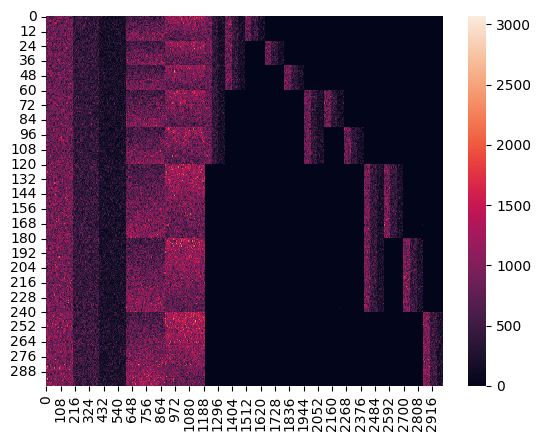

In [6]:
adata_tmp = adata.copy()
sc.pp.normalize_total(adata_tmp, target_sum=1e6)
sns.heatmap(adata_tmp.X)

In [7]:
entropy_score = imbalance_entropy(adata, key='cell_type')
print("Entropy score:", entropy_score)

Cell type counts: cell_type
C1    60
C2    60
D     60
B1    30
B2    30
A1    20
A2    20
A3    20
Name: count, dtype: int64
Entropy score: 1.9677898062797112


## 亚型

In [8]:
adata.var_names

Index(['gRoot_gb0_0', 'gRoot_gb0_1', 'gRoot_gb0_2', 'gRoot_gb0_3',
       'gRoot_gb0_4', 'gRoot_gb0_5', 'gRoot_gb0_6', 'gRoot_gb0_7',
       'gRoot_gb0_8', 'gRoot_gb0_9',
       ...
       'gD_gb2_40', 'gD_gb2_41', 'gD_gb2_42', 'gD_gb2_43', 'gD_gb2_44',
       'gD_gb2_45', 'gD_gb2_46', 'gD_gb2_47', 'gD_gb2_48', 'gD_gb2_49'],
      dtype='object', length=3000)

## Sunburnt 图

In [9]:
import xml.etree.ElementTree as ET
import pandas as pd
import plotly.graph_objects as go
import colorsys

xml_file = SIM_PATH + f"/sim_data/trees/tree_{data_id}.xml"
tree = ET.parse(xml_file)
root = tree.getroot()

data = []

def get_tree_height(node):
    """递归计算 celltype 的最大深度"""
    if node.tag != "celltype":
        return 0
    if not any(child.tag == "celltype" for child in node):
        return 1
    return 1 + max(get_tree_height(child) for child in node if child.tag == "celltype")

MAX_HEIGHT = max(get_tree_height(child) for child in root if child.tag == "celltype") + 1 # 加一因为plotly默认子节点透明

def parse_celltype(node, parent_name=None, current_depth=1):
    """递归解析 XML，只处理 <celltype>，并补齐虚拟节点"""
    if node.tag != "celltype":
        return

    name = node.attrib["name"]
    num_cells = int(node.attrib.get("num_cells", 0))

    entry = {
        "id": name,
        "parent": parent_name,
        "num_cells": num_cells,
        "is_virtual": False
    }
    data.append(entry)

    # 子 celltype 节点
    children = [child for child in node if child.tag == "celltype"]

    if children:
        for child in children:
            parse_celltype(child, parent_name=name, current_depth=current_depth+1)
    else:
        # 如果是叶子但没到最大深度，补虚拟节点
        depth = current_depth
        parent = name
        while depth < MAX_HEIGHT:
            virtual_name = f"{name}_v{depth}"
            data.append({
                "id": virtual_name,
                "parent": parent,
                "num_cells": num_cells,  # 沿用叶子数量
                "is_virtual": True
            })
            parent = virtual_name
            depth += 1

# 遍历根节点下的 celltype
for child in root:
    if child.tag == "celltype":
        parse_celltype(child, parent_name=None)

# 转 DataFrame
df = pd.DataFrame(data)

# 颜色
# def assign_colors(df):
#     color_map = {}

#     # 给顶层大类分配基础色相
#     base_hues = [0.0, 0.33, 0.66]  # 红、绿、蓝
#     top_level = df[df["parent"]=='Root']["id"].tolist()

#     for i, cat in enumerate(top_level):
#         H_base = base_hues[i % len(base_hues)]
#         color_map[cat] = hsl_to_rgb_str(H_base, 0.7, 0.7)

#         # 直接子类
#         children = df[df["parent"]==cat].to_dict('records')
#         n = len(children)
#         for j, child in enumerate(children):
#             if child.get("is_virtual", False):
#                 # 虚拟节点继承父类颜色
#                 color_map[child["id"]] = color_map[cat]
#             else:
#                 # 正常分配 hue
#                 offsets = np.linspace(-0.1, 0.1, n)
#                 H_child = (H_base + offsets[j]) % 1.0
#                 color_map[child["id"]] = hsl_to_rgb_str(H_child, 0.7, 0.7)

#             # 孙子节点
#             grandchildren = df[df["parent"]==child["id"]].to_dict('records')
#             m = len(grandchildren)
#             for k, gc in enumerate(grandchildren):
#                 if gc.get("is_virtual", False):
#                     color_map[gc["id"]] = color_map[child["id"]]
#                 else:
#                     # 正常分配 hue
#                     offsets_gc = np.linspace(-0.05, 0.05, max(1, m))
#                     H_gc = (H_child + offsets_gc[k]) % 1.0
#                     color_map[gc["id"]] = hsl_to_rgb_str(H_gc, 0.7, 0.7)

#     return color_map


# def hsl_to_rgb_str(h, s, l):
#     r, g, b = colorsys.hls_to_rgb(h, l, s)
#     return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"

# color_map = assign_colors(df)
# df["color"] = df["id"].map(color_map)

def mean_rgb(colors):
    """取一组 rgb(...) 颜色的均值"""
    rgbs = []
    for c in colors:
        if not c or (isinstance(c, float) and np.isnan(c)):
            continue
        r, g, b = map(int, c.strip("rgb() ").split(","))
        rgbs.append((r, g, b))
    if not rgbs:
        return None
    arr = np.array(rgbs)
    r, g, b = arr.mean(axis=0).astype(int)
    return f"rgb({r},{g},{b})"

def assign_colors(df):

    # 莫兰迪
    base_colors = {
        "A1_v4": "rgb(255, 204, 204)",  # 浅粉（A 类，暖色）
        "A2_v4": "rgb(245, 223, 184)",  # 暖黄（A 类，暖色）
        "A3_v4": "rgb(240, 173, 141)",  # 珊瑚橙（A 类，暖色）
        "B1_v4": "rgb(120, 141, 171)",  # 深海蓝（B 类，冷色）
        "B2_v4": "rgb(161, 191, 161)",  # 橄榄绿（B 类，冷色）
        "C1_v4": "rgb(179, 157, 185)",  # 淡紫（C 类，紫色系）
        "C2_v4": "rgb(224, 187, 228)",  # 粉紫（C 类，紫色系）
        "D_v4":  "rgb(165, 145, 125)"   # 土棕（D 类，中性）
    }

    # # pastel
    # base_colors = {
    #     "A1_v4": "rgb(255, 182, 193)",  # 粉红（A 类，pastel 暖色）
    #     "A2_v4": "rgb(255, 204, 153)",  # 浅橙（A 类，pastel 暖色）
    #     "A3_v4": "rgb(255, 229, 153)",  # 浅黄（A 类，pastel 暖色）
    #     "B1_v4": "rgb(135, 206, 235)",  # 天蓝（B 类，pastel 冷色）
    #     "B2_v4": "rgb(152, 251, 152)",  # 薄荷绿（B 类，pastel 冷色）
    #     "C1_v4": "rgb(186, 151, 201)",  # 淡紫（C 类，pastel 紫色）
    #     "C2_v4": "rgb(221, 160, 221)",  # 梅子紫（C 类，pastel 紫色）
    #     "D_v4":  "rgb(188, 143, 143)"   # 玫瑰棕（D 类，pastel 中性）
    # }

    # # modern
    # base_colors = {
    #     "A1_v4": "rgb(200, 35, 45)",    # 宝石红（A 类，深暖色）
    #     "A2_v4": "rgb(220, 90, 80)",    # 珊瑚红（A 类，深暖色）
    #     "A3_v4": "rgb(240, 140, 70)",   # 琥珀橙（A 类，深暖色）
    #     "B1_v4": "rgb(40, 80, 120)",    # 海军蓝（B 类，深冷色）
    #     "B2_v4": "rgb(80, 160, 140)",   # 翡翠绿（B 类，深冷色）
    #     "C1_v4": "rgb(100, 80, 160)",   # 深紫（C 类，紫色系）
    #     "C2_v4": "rgb(140, 120, 180)",  # 青紫（C 类，紫色系）
    #     "D_v4":  "rgb(120, 100, 90)"    # 深灰棕（D 类，中性）
    # }

    df["color"] = None
    for node, col in base_colors.items():
        df.loc[df["id"] == node, "color"] = col

    # 逐层更新父节点颜色 = 子类均值
    unresolved = True
    while unresolved:
        unresolved = False
        for i, row in df.iterrows():
            if not row["color"] or (isinstance(row["color"], float) and np.isnan(row["color"])):
                children = df[df["parent"] == row["id"]]["color"].tolist()
                col = mean_rgb(children)
                if col:
                    df.at[i, "color"] = col
                else:
                    unresolved = True  # 等待子类颜色填充

    return df
# 用法：
df = assign_colors(df)

# Sunburst
fig = go.Figure(go.Sunburst(
    labels=df['id'],
    parents=df['parent'],
    values=df['num_cells'],
    branchvalues='total',
    hoverinfo='label+value+percent parent',
    marker=dict(colors=df["color"],
                line=dict(width=0)),
))
fig.update_traces(maxdepth=MAX_HEIGHT - 1)
fig.update_traces(
    textfont=dict(
        color=[ 'rgba(0,0,0,0)' if v else 'black' for v in df['is_virtual'] ]
    )
)
fig.update_layout(margin=dict(t=10, l=10, r=10, b=10))
fig.show()

print(df)

       id parent  num_cells  is_virtual               color
0    Root   None        300       False    rgb(186,166,167)
1      R1   Root        120       False    rgb(193,183,171)
2      R3     R1         60       False    rgb(246,200,176)
3      A1     R3         20       False    rgb(255,204,204)
4   A1_v4     A1         20        True  rgb(255, 204, 204)
5      A2     R3         20       False    rgb(245,223,184)
6   A2_v4     A2         20        True  rgb(245, 223, 184)
7      A3     R3         20       False    rgb(240,173,141)
8   A3_v4     A3         20        True  rgb(240, 173, 141)
9      R4     R1         60       False    rgb(140,166,166)
10     B1     R4         30       False    rgb(120,141,171)
11  B1_v4     B1         30        True  rgb(120, 141, 171)
12     B2     R4         30       False    rgb(161,191,161)
13  B2_v4     B2         30        True  rgb(161, 191, 161)
14     R2   Root        120       False    rgb(201,172,206)
15     C1     R2         60       False 

# 跑方法

## MULE

In [10]:
# 处理数据
def mule_process(adata, opposite_graph_threshold = 0.8, subgraph_threshold=3, merge_threshold=1):
    adata = adata.copy()
    # sc.pp.normalize_total(adata, target_sum=1e6)
    # sc.pp.log1p(adata)
    # sc.pp.scale(adata)
    mu.pre_process.hvg(adata)
    sns.heatmap(adata.X)
    adata = adata[:,adata.var['highly_variable'] == True]
    mu.tax.mutually_exclusively_detect_CME(adata)
    mu.vis.polar_score(adata)

    mu.tax.build_opposite_graph(adata, threshold = opposite_graph_threshold)
    mu.vis.graph_degree(adata)

    mu.tax.get_subgraph(adata,threshold=subgraph_threshold)
    mu.vis.merge_strategy(adata)

    mu.tax.bipartite_embedding_perm_fast(adata,merge_threshold=merge_threshold)
    mu.vis.oppo_filter_graph(adata)
    mu.vis.mode_graph(adata)

    mu.tax.build_taxonomy_tree(adata)
    mu.tax.cal_scpurity_cme_parallel(adata)

    mu.tax.mule_umap(adata, ['mode 0', 'mode 1'])
    sc.tl.score_genes(adata, gene_list=adata.uns['mule']['mode info']['mode 1'])
    sc.pl.embedding(adata, basis='X_umap_mule', color = 'score')

    tree = mu.vis.plot_taxonomy_tree(adata)
    Image(tree.create_png())

    return adata

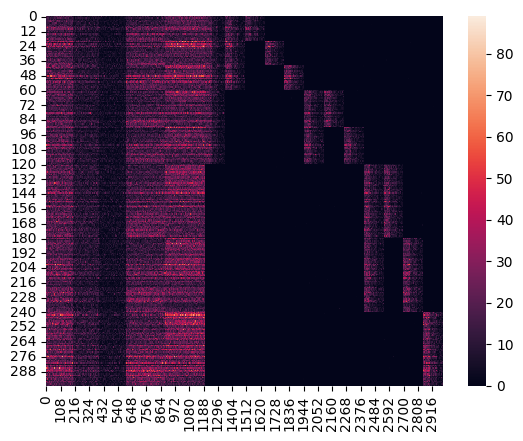

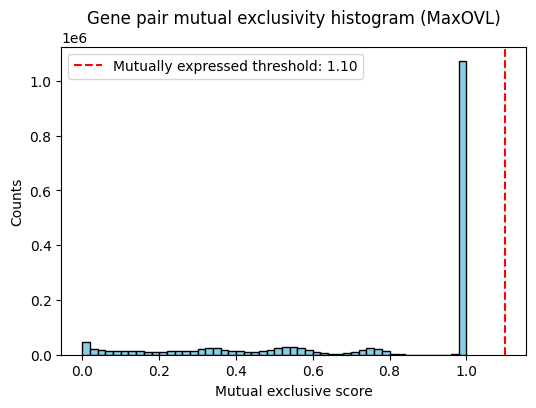

Build mutually exclusive gene graph
Calculate original graph degree


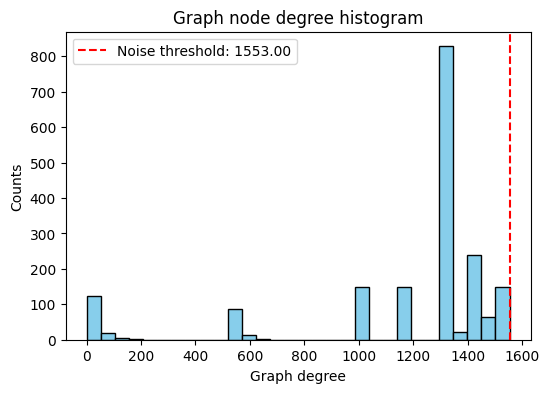

Filter low-degree nodes (denoise genes)


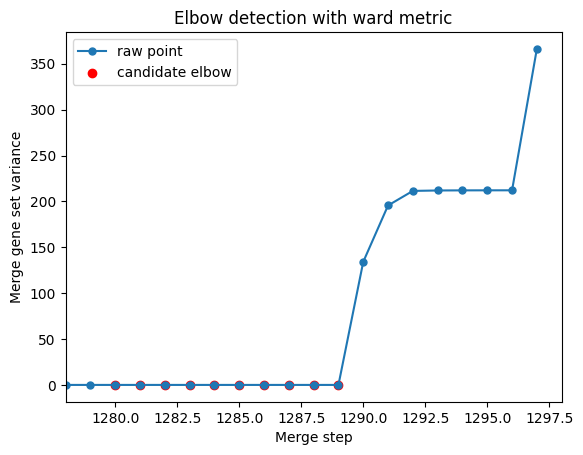

Linkage info (last 20 steps):
1278      0.000000
1279      0.000000
1280      0.000000
1281      0.000000
1282      0.000000
1283      0.000000
1284      0.000000
1285      0.000000
1286      0.000000
1287      0.000000
1288      0.000000
1289      0.000000
1290    134.164079
1291    195.576072
1292    211.423745
1293    211.897252
1294    212.014872
1295    212.061807
1296    212.085245
1297    366.160619
Name: 2, dtype: float64
plot the opposite filter graph


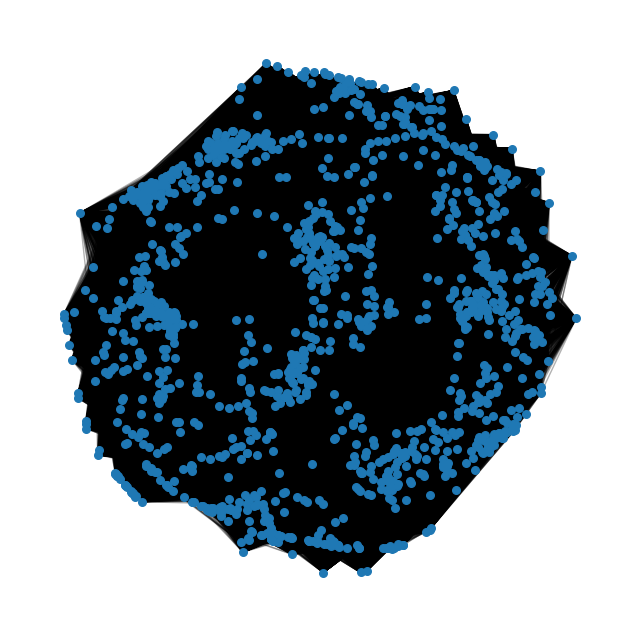

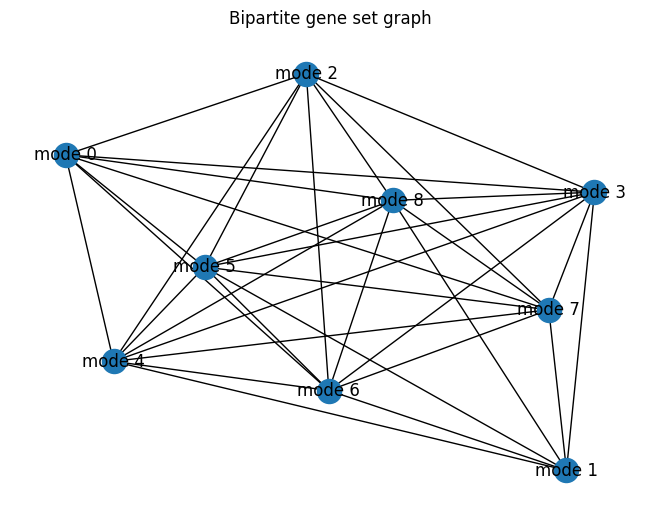

Create a root marker set
root set
├── mode 1
│   ├── mode 0
│   └── mode 2
├── mode 3
├── mode 4
├── mode 5
├── mode 6
├── mode 7
└── mode 8

Calculate scPurity using CME scores with parallel permutation test
scPurity: 0.9572426883934178 p_value: 1.0


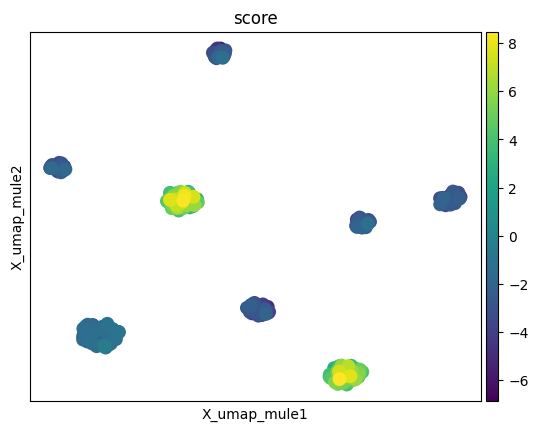

In [11]:
adata_mule = mule_process(adata, opposite_graph_threshold = 0.8, subgraph_threshold=1250, merge_threshold=100)

CME_score_df = adata_mule.uns['mule']['opposite score']

result_df = adata_mule.uns['mule']['graph_degree']
result_df.index = result_df['gene']

mule_genes = []
for mode in adata_mule.uns['mule']['mode info']:
    mule_genes = mule_genes + adata_mule.uns['mule']['mode info'][mode]
mule_result = dict()
mule_result['genes'] = []
mule_result['scores'] = []
for gene in result_df.index:
    if gene in mule_genes:
        mule_result['genes'] = mule_result['genes'] + [gene]
        mule_result['scores'] = mule_result['scores'] + [result_df.loc[gene, 'degree']]

## hvg

In [12]:
def run_hvg(adata):
    adata_copy = adata.copy()
    sc.pp.normalize_total(adata_copy)
    sc.pp.log1p(adata_copy)
    sc.pp.scale(adata_copy)
    sc.pp.highly_variable_genes(adata_copy, min_mean=0.0125, max_mean=3, min_disp=0.5)
    return {
        "genes": adata_copy.var.index[adata_copy.var['highly_variable']].to_numpy(),
        "scores": adata_copy.var['highly_variable'].values
    }

## Anti-Corr

In [13]:
def run_anticorrelation(adata):
    adata_copy = adata.copy()
    sc.pp.normalize_total(adata_copy)
    
    anti_cor_table = get_anti_cor_genes(
        adata_copy.X.T,
        adata_copy.var.index.tolist(),
        species="hsapiens",
        pre_remove_pathways=[],
        FPR=0.0002,
        FDR=1/40
    )
    selected_table = anti_cor_table[anti_cor_table["selected"]==True]
    return {
        "genes": selected_table.index.to_numpy(),
        "scores": -np.array(selected_table['FDR'].to_list())
    }

## GiniClust

In [14]:
def run_gini(adata):
    adata_copy = adata.copy()
    sc.pp.log1p(adata_copy)
    gc.gini.calGini(adata_copy, min_gini_value=0.1, neighbors=3, p_value=0.05)
    return {
        "genes": adata_copy.var.index.to_numpy(),
        "scores": adata_copy.var['gini_value'].values
    }

## EEI

In [15]:
import scanpy as sc
import pandas as pd
import numpy as np
import subprocess
import os
import tempfile
import sys

def run_eei(adata, eeisp_script="/home/luting/projects/TAMER/EEISP/eeisp.py", gene_name_script="/home/luting/projects/TAMER/EEISP/gene_name.py", threshold=0.8):
    """
    运行 EEISP -> gene_name 完整流程
    参数：
    - adata: AnnData 对象
    - eeisp_script: EEISP 脚本路径
    - gene_name_script: gene_name 脚本路径
    - threshold: 阈值，越大筛选越猛（越少）

    返回：
    - genes: 经过筛选(score > threshold)并按分数降序排列的基因名
    - scores: 对应的分数
    """
    # 1. 数据准备
    df = adata.to_df().T
    
    # 过滤掉全零表达的基因
    valid_genes_mask = df.sum(axis=1) > 0
    df_filtered = df.loc[valid_genes_mask]
    
    # 2. 准备临时环境
    with tempfile.TemporaryDirectory() as temp_dir:
        input_file = "data.txt"
        output_prefix = "Sample"
        
        # 3. 导出数据
        df_filtered.index.name = None 
        df_filtered.to_csv(os.path.join(temp_dir, input_file), sep=',', header=True, index=True)
        
        # --- 第一步: 运行 eeisp.py ---
        # 注意：这里传入的 threshold 决定了 EEISP 算法只会输出分数大于该值的基因对
        cmd_eeisp = [
            sys.executable, eeisp_script,
            input_file,
            output_prefix,
            "--threEEI", str(threshold),
            "--threCDI", str(threshold)
        ]
        
        print(f"1. Running eeisp.py (threshold={threshold})...")
        p1 = subprocess.run(cmd_eeisp, capture_output=True, text=True, cwd=temp_dir)
        
        # 错误处理逻辑 (保持原样)
        if p1.returncode != 0:
            if "empty sequence" in p1.stderr or "division by zero" in p1.stderr:
                print("警告: 未找到显著互斥对。")
                return {"genes": np.array([]), "scores": np.array([])}
            else:
                raise RuntimeError(f"EEISP Error:\n{p1.stderr}")

        # --- 第二步: 运行 gene_name.py ---
        file_cdi = f"{output_prefix}_CDI_score_data_thre{threshold}.txt"
        file_eei = f"{output_prefix}_EEI_score_data_thre{threshold}.txt"
        file_exp = f"{output_prefix}_number_nonzero_exp.txt"
        
        cmd_gene_name = [
            sys.executable, gene_name_script,
            output_prefix,
            file_cdi,
            file_eei,
            file_exp,
            str(threshold)
        ]
        
        print("2. Running gene_name.py...")
        p2 = subprocess.run(cmd_gene_name, capture_output=True, text=True, cwd=temp_dir)
        
        if p2.returncode != 0:
            print(f"警告: gene_name.py 运行异常 (可能无结果): {p2.stderr}")
            return {"genes": np.array([]), "scores": np.array([])}

        # --- 第三步: 读取并处理结果 ---
        final_file = f"{output_prefix}_EEI_convert_data_thre{threshold}.txt"
        final_path = os.path.join(temp_dir, final_file)
        
        # 初始化全 0 数组，用于对齐
        all_scores = np.zeros(adata.n_vars)
        
        if os.path.exists(final_path):
            try:
                df_res = pd.read_csv(final_path, sep='\t', names=['G1', 'G2', 'Score'])
                
                if not df_res.empty:
                    # 计算每个基因的最大分数
                    part1 = df_res[['G1', 'Score']].rename(columns={'G1': 'Gene'})
                    part2 = df_res[['G2', 'Score']].rename(columns={'G2': 'Gene'})
                    combined = pd.concat([part1, part2])
                    
                    max_scores_series = combined.groupby('Gene')['Score'].max()
                    
                    # 对齐到 adata 的所有基因 (未出现的补0)
                    all_scores = max_scores_series.reindex(adata.var_names, fill_value=0).values
                    print(f"Success: Processed {len(max_scores_series)} unique genes.")
            except Exception as e:
                print(f"结果解析失败: {e}")
        else:
            print("未找到最终结果文件。")

    # --- 第四步: 筛选和排序 ---
    
    # 1. 获取所有基因名
    all_genes = adata.var_names.to_numpy()
    
    # 2. 筛选 (mask): 
    # 因为 EEISP 算法本身已经通过命令行参数 `--threEEI` 过滤了结果，
    # 所以凡是能在结果文件中出现的基因，其分数一定 >= threshold。
    # 这里的 `all_scores > 0` 就等同于筛选出了算法返回的基因。
    mask = all_scores > 0
    
    filtered_genes = all_genes[mask]
    filtered_scores = all_scores[mask]
    
    # 3. 排序 (从高到低)
    sort_idx = np.argsort(filtered_scores)[::-1]

    return {
        "genes": filtered_genes[sort_idx],
        "scores": filtered_scores[sort_idx]
    }

## scHayStack

In [16]:
def dimension_reduce(adata):
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=20, n_pcs=20)
    return adata

In [17]:
import scanpy as sc
import numpy as np
# 假设 import haystack as hs 已经存在

def run_haystack(adata, threshold=-0.1):
    """
    运行 Haystack 方法
    参数:
        threshold: 分数阈值 (默认 -0.1，即筛选 p_adj < 0.1 的基因)
    返回:
        genes: 基因索引 (adata.var_names)
        scores: 对应的负对数分数 (-pval_adj)
    """
    adata_copy = adata.copy()
    adata_copy.layers["counts"] = adata_copy.X.copy()
    sc.pp.normalize_total(adata_copy)
    sc.pp.log1p(adata_copy)
    
    # 假设 dimension_reduce 是你外部定义的函数
    adata_copy = dimension_reduce(adata_copy)
    
    # 运行 Haystack
    # res.result 的 index 自动对应 adata.var_names
    res = hs.haystack(adata_copy, coord="X_pca")
    
    # 1. 获取数据 (转为 numpy 以防 pandas 索引报错)
    all_genes = adata.var_names[res.result.index.to_numpy()]
    all_scores = -res.result['pval_adj'].values
    
    # 2. 筛选 (Score > -0.1)
    mask = all_scores > threshold
    
    filtered_genes = all_genes[mask]
    filtered_scores = all_scores[mask]
    
    # 3. 排序 (分数从高到低 -> 即 p-value 从小到大)
    sort_idx = np.argsort(filtered_scores)[::-1]
    
    return {
        "genes": filtered_genes[sort_idx],
        "scores": filtered_scores[sort_idx]
    }

## semitones

In [18]:
import scanpy as sc
import numpy as np
# 假设 pairwise_kernels, dimension_reduce, from_knn_dist, pairwise_similarities, calculate_escores 已经导入

def run_semitones(adata, threshold=0.03):
    """
    运行 Semitones 方法
    参数:
        adata: AnnData 对象
        threshold: 过滤分数的阈值，默认 0.03。
    返回:
        字典，包含筛选后且排序的 genes 和 scores
    """
    adata_copy = adata.copy()
    adata_copy.layers["counts"] = adata_copy.X.copy()
    sc.pp.normalize_total(adata_copy)
    sc.pp.log1p(adata_copy)
    adata_copy = dimension_reduce(adata_copy)

    S = pairwise_kernels(adata_copy.obsm['X_pca'], metric="rbf", gamma=8.6e-4)
    median = np.median(S, axis=0)
    start = int(np.argmin(median))

    dd_rcells = from_knn_dist(
        X=adata_copy.obsm['X_pca'],
        n_ret=17,
        start=start,
        metric_params={"gamma": 8.6e-4}
    )
    S = pairwise_similarities(adata_copy.obsm['X_pca'], query=dd_rcells, metric_params={"gamma": 8.6e-4})

    escores = calculate_escores(adata_copy.X, query=dd_rcells, S=S)
    
    # 1. 获取所有基因的分数（取每行最大值）和基因名
    # 注意：这里假设 escores 的形状使得 axis=1 对应基因的聚合分数
    all_scores = escores.max(axis=1)
    if hasattr(all_scores, "values"):
        all_scores = all_scores.values
    all_genes = adata_copy.var.index.to_numpy()
    
    # 2. 创建掩码 (Mask)：找出分数大于 threshold 的位置
    mask = all_scores > threshold
    
    # 3. 应用掩码进行筛选
    filtered_genes = all_genes[mask]
    filtered_scores = all_scores[mask]
    
    # 4. (可选) 按分数从高到低排序
    # np.argsort 返回的是从小到大的索引，所以用 [::-1] 反转
    sort_idx = np.argsort(filtered_scores)[::-1]
    
    return {
        "genes": filtered_genes[sort_idx],
        "scores": filtered_scores[sort_idx]
    }

Start enrichment scoring
Enrichment scoring complete


(array([ 7., 13., 18., 23., 25., 23.,  4.,  4.,  4.,  3.]),
 array([0.0300381 , 0.03059143, 0.03114475, 0.03169808, 0.03225141,
        0.03280474, 0.03335806, 0.03391139, 0.03446472, 0.03501805,
        0.03557137]),
 <BarContainer object of 10 artists>)

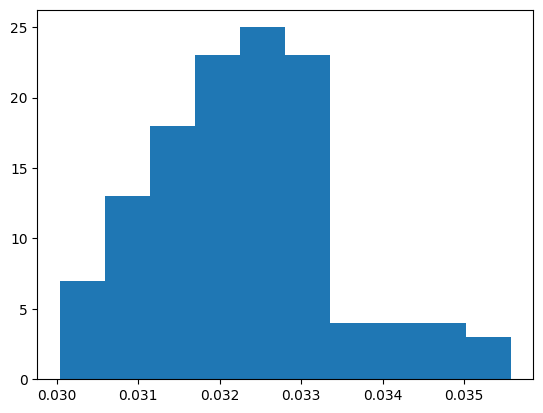

In [19]:
semitones_result = run_semitones(adata)
plt.hist(semitones_result['scores'])

## DubStepR

In [20]:
def run_dubstepr(adata):
    data_df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    dubstepr_genes = analyze_gene_correlations(data_df, n_bins=15)
    return {
        "genes": dubstepr_genes[0],
        "scores": dubstepr_genes[1]
    }
# print(f"Found {len(dubstepr_genes)} genes with high correlation range")
# print("Selected genes:", dubstepr_genes)  # Print first 10 genes
# plot_cell_gene_heatmap(data_df, selected_genes, title='Cell-Gene Expression Heatmap\n(DubStepR Selected Genes in Yellow)')

## MarcoPolo

In [21]:
def run_marcopolo(adata, top_n=500):
    """
    运行 MarcoPolo 算法并返回 Top N Marker 基因
    
    Args:
        adata: AnnData 对象
        top_n: 返回排名前多少的基因，默认为 50
    """
    adata_copy = adata.copy()
    
    # --- 1. 预处理 ---
    if "size_factor" not in adata_copy.obs.columns:
        norm_factor = sc.pp.normalize_total(
            adata_copy, 
            exclude_highly_expressed=True, 
            max_fraction=0.2, 
            inplace=False
        )["norm_factor"]
        adata_copy.obs["size_factor"] = norm_factor / norm_factor.mean()
        print("已计算 Size Factor。")
    
    # --- 2. 设备检测 ---
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    print(f"正在运行 MarcoPolo (Device: {device})...")
    
    # --- 3. 运行回归 ---
    regression_result = MarcoPolo.run_regression(
        adata=adata_copy,
        size_factor_key="size_factor",
        num_threads=32,
        device=device
    )
    
    # --- 4. 寻找标记基因 ---
    markers_result = MarcoPolo.find_markers(
        adata=adata_copy,
        regression_result=regression_result
    )
    
    # --- 5. 排序与提取结果 ---
    print(f"原始列名: {markers_result.columns.tolist()}")
    
    # 优先使用的评分列名列表
    target_score_col = None
    target_rank_col = None
    
    # 检查是否存在标准的 MarcoPolo 字段
    if 'MarcoPolo' in markers_result.columns:
        target_score_col = 'MarcoPolo'
        target_rank_col = 'MarcoPolo_rank' # 既然有Score通常也有Rank
    elif 'MarcoPolo_score' in markers_result.columns:
        target_score_col = 'MarcoPolo_score'
    else:
        # 兜底：如果找不到，使用你的日志中出现的 'MS' 或者第一列数值
        target_score_col = markers_result.select_dtypes(include=[np.number]).columns[0]
        print(f"警告: 未找到标准 'MarcoPolo' 字段，降级使用 '{target_score_col}'。")

    print(f"正在提取 Top {top_n} (基于评分列: {target_score_col})...")

    # 逻辑分支：如果有 Rank 列，直接按 Rank 排序（升序）；否则按 Score 排序（降序）
    if target_rank_col and target_rank_col in markers_result.columns:
        # 按排名升序 (1, 2, 3...)
        sorted_df = markers_result.sort_values(by=target_rank_col, ascending=True)
    else:
        # 按分数降序 (高分在前)
        sorted_df = markers_result.sort_values(by=target_score_col, ascending=False)
    
    # 截取前 N 个
    top_genes_df = sorted_df.head(top_n)
    
    # 获取基因名（假设索引是基因名）
    top_genes = adata.var_names[top_genes_df.index.to_numpy()]
    top_scores = top_genes_df[target_score_col].values
    
    # 如果你也想看具体的 rank 值（如果有的话）
    top_ranks = top_genes_df[target_rank_col].values if target_rank_col else np.arange(1, top_n + 1)

    # 打印预览
    print(f"Top 3 Genes: {top_genes[:3]}")
    
    return {
        "genes": top_genes,      # 排序后的 Top N 基因名
        "scores": top_scores     # 对应的分数
    }

## 可用方法列表

In [22]:
METHODS = {
    "HVG": run_hvg,
    "scHaystack": run_haystack,
    "EEI": run_eei,
    "Anti-correlation": run_anticorrelation,
    # "Gini": run_gini,
    "DubStepR": run_dubstepr,
    "Semitones": run_semitones,
    "MarcoPolo": run_marcopolo
}

In [23]:
def evaluate_methods(adata, method_names):
    """
    输入要运行的方法名称列表，输出 {方法名: {"genes": ..., "scores": ...}}
    """
    results = {}
    for name in method_names:
        if name not in METHODS:
            raise ValueError(f"方法 {name} 不在支持列表中: {list(METHODS.keys())}")
        print(f"Running {name} ...")
        results[name] = METHODS[name](adata)
    return results

In [24]:
method_list = ["HVG", "scHaystack", "EEI", "Anti-correlation", "DubStepR", "Semitones", "MarcoPolo"]
results = evaluate_methods(adata, method_list)
results['MULE'] = mule_result

Running HVG ...
Running scHaystack ...
> starting haystack ...
> entering array method ...
> scaling coordinates ...
> calculating feature stds ...
> calculating grid points ...
> calculating distance to cells ...
> calculating densities ...
> calculating Q dist ...
> calculating KLD for 3000 features ...


100%|██████████| 3000/3000 [00:00<00:00, 15405.43it/s]


> calculating feature's CV ...
> selecting genes to randomize ...
> calculating randomized KLD ...


100%|██████████| 100/100 [00:00<00:00, 159.05it/s]


> calculating P values ...
> done.
Running EEI ...
1. Running eeisp.py (threshold=0.8)...
2. Running gene_name.py...
Success: Processed 1965 unique genes.
Running Anti-correlation ...
found 1023.494909952 free Gb in /tmp
get_all_remove_genes
300 15
min_express_n 15
get_n_expressed
pre_remove_feature: 0
pre_remove_pathway: 0
pre_remove_low_express: 0
0  genes to remove out of  3000
rewriting the filtered dataset
/tmp/exprs.hdf5
total_vars: 3000
making the hdf5 spearman output file
/tmp/spearman.hdf5
Getting the Spearman correlations
total_vars 3000
empirically determined Cneg cutoff: -0.20402671140790452  for FPR of: 0.0002
empirically determined Cpos cutoff: 0.2519398796980746  for FPR of: 0.0002
get_real_spear
[0, 3000]
working on 0 3000 vs 0 3000
Running DubStepR ...
Running Semitones ...
Start enrichment scoring
Enrichment scoring complete
Running MarcoPolo ...
已计算 Size Factor。
正在运行 MarcoPolo (Device: cuda:0)...
<INFO> Currently, you are using 32 threads for regression. If you encou

# 对比

## Ground Truth

In [25]:
all_genes = [gene for gene in data_df.columns]
all_markers = [gene for gene in data_df.columns if not gene.startswith("gRoot")]
pattern = re.compile(r"^g(" + "|".join(adata.obs['cell_type'].value_counts().index.categories) + r")")
subtype_markers = [gene for gene in data_df.columns if pattern.match(gene)] #  or gene.startswith("gRoot")

# # 选择使用什么 marker
# marker_type = int(input("请输入想使用大类/亚型 marker（全部输入0，大类输入 1，亚型输入 2）："))
# if marker_type==0:
#     markers_used = all_genes
# elif marker_type==1:
#     markers_used = all_markers
# else:
#     markers_used = subtype_markers

## ROC 图

In [26]:
def ROC(label, method_results, gene_names=None):
    """
    绘制多方法的 ROC 曲线，优化为 PPT 展示风格，带渐变填充和高对比度。
    - label: 对应所有基因的二分类标签数组，长度 = len(gene_names)
    - method_results: 字典，每个方法包含 'genes' 和 'scores'
    - gene_names: 如果 label 对应的是 adata.var_names，可以传入或用全局 adata.var_names
    """
    # 设置 PPT 风格的字体和全局参数
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.linewidth'] = 0.6
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.linestyle'] = ':'
    plt.rcParams['grid.alpha'] = 0.2

    if gene_names is None:
        gene_names = adata.var_names  # 使用全局 adata.var_names

    # PPT 风格配色，鲜艳且现代
    colors = ['#1E88E5', '#D81B60', '#FFC107', '#004D40', '#8E24AA', '#F4511E']
    # 定义渐变填充
    cmaps = [
        LinearSegmentedColormap.from_list('custom', ['#FFFFFF', c], N=256) for c in colors
    ]
    names = list(method_results.keys())

    # 设置图形大小，适合 PPT 16:9（6×3.375英寸）
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    for i, name in enumerate(names):
        res = method_results[name]
        genes = res['genes']
        scores = res['scores']

        # 判断 scores 是完整基因分数还是仅对应 genes
        print(name, "scores type:")
        print(type(scores), "scores same as genes count", len(scores)==len(genes))
        if len(scores) == len(genes):
            sorted_indices = np.argsort(scores)[::-1]
            sorted_genes = [genes[j] for j in sorted_indices]
            sorted_scores = [scores[j] for j in sorted_indices]
            gene_to_score = dict(zip(sorted_genes, sorted_scores))
            scores_array = np.array([gene_to_score.get(g, 0) for g in gene_names])
        elif len(scores) == len(label):
            scores_array = np.array(scores)
            scores_array = np.nan_to_num(scores_array, nan=0.0, posinf=0.0, neginf=0.0)
        else:
            raise ValueError(f"{name}: scores 长度不符合 genes 或 label 的长度！")

        # 计算 ROC
        fpr, tpr, _ = roc_curve(label, scores_array)
        roc_auc = auc(fpr, tpr)

        # 绘制 ROC 曲线和渐变填充
        ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, alpha=0.9,
                label=f'{name} (AUC = {roc_auc:.3f})')
        ax.fill_between(fpr, tpr, color=colors[i % len(colors)], alpha=0.15, cmap=cmaps[i % len(cmaps)])

        # 打印 AUC
        print(f"{name}: AUC = {roc_auc:.4f}")

    # 设置坐标轴标签和标题
    ax.set_xlabel('False Positive Rate', fontsize=12, weight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=12, weight='bold')
    ax.set_title('ROC Curves', fontsize=14, weight='bold', pad=10)

    # 设置坐标轴范围和刻度
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_yticks(np.arange(0, 1.1, 0.2))

    # 添加网格
    ax.grid(True, linestyle=':', alpha=0.2, color='#333333')

    # 优化图例
    ax.legend(fontsize=6, frameon=True, edgecolor='none', bbox_to_anchor=[1, 1.05])

    # 设置边框线条
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(0.6)

    # 调整布局
    plt.tight_layout()
    plt.show()

In [27]:
results

{'HVG': {'genes': array(['gRoot_gb0_1', 'gRoot_gb0_3', 'gRoot_gb0_4', 'gRoot_gb0_5',
         'gRoot_gb0_6', 'gRoot_gb0_8', 'gRoot_gb0_9', 'gRoot_gb0_10',
         'gRoot_gb0_13', 'gRoot_gb0_14', 'gRoot_gb0_15', 'gRoot_gb0_19',
         'gRoot_gb0_25', 'gRoot_gb0_26', 'gRoot_gb0_34', 'gRoot_gb0_35',
         'gRoot_gb0_37', 'gRoot_gb0_41', 'gRoot_gb0_42', 'gRoot_gb0_44',
         'gRoot_gb0_45', 'gRoot_gb0_52', 'gRoot_gb0_54', 'gRoot_gb0_55',
         'gRoot_gb0_56', 'gRoot_gb0_61', 'gRoot_gb0_64', 'gRoot_gb0_68',
         'gRoot_gb0_69', 'gRoot_gb0_71', 'gRoot_gb0_72', 'gRoot_gb0_74',
         'gRoot_gb0_75', 'gRoot_gb0_76', 'gRoot_gb0_78', 'gRoot_gb0_82',
         'gRoot_gb0_83', 'gRoot_gb0_86', 'gRoot_gb0_89', 'gRoot_gb0_90',
         'gRoot_gb0_91', 'gRoot_gb0_92', 'gRoot_gb0_93', 'gRoot_gb0_94',
         'gRoot_gb0_95', 'gRoot_gb0_97', 'gRoot_gb0_99', 'gRoot_gb0_100',
         'gRoot_gb0_101', 'gRoot_gb0_103', 'gRoot_gb0_104', 'gRoot_gb0_105',
         'gRoot_gb0_106', 'gRoot_gb0_

In [28]:
for result_tmp in results:
    print(result_tmp, len(results[result_tmp]['scores']))

HVG 3000
scHaystack 796
EEI 1965
Anti-correlation 1655
DubStepR 893
Semitones 124
MarcoPolo 500
MULE 1299


In [29]:
results['DubStepR']['genes'][1]

'gA1_gb2_1'

HVG scores type:
<class 'numpy.ndarray'> scores same as genes count False
HVG: AUC = 0.4817
scHaystack scores type:
<class 'numpy.ndarray'> scores same as genes count True
scHaystack: AUC = 0.3054
EEI scores type:
<class 'numpy.ndarray'> scores same as genes count True
EEI: AUC = 0.9958
Anti-correlation scores type:
<class 'numpy.ndarray'> scores same as genes count True
Anti-correlation: AUC = 0.4762
DubStepR scores type:
<class 'list'> scores same as genes count True
DubStepR: AUC = 0.5411
Semitones scores type:
<class 'numpy.ndarray'> scores same as genes count True
Semitones: AUC = 0.5344
MarcoPolo scores type:
<class 'numpy.ndarray'> scores same as genes count True
MarcoPolo: AUC = 0.6378
MULE scores type:
<class 'list'> scores same as genes count True
MULE: AUC = 0.8608


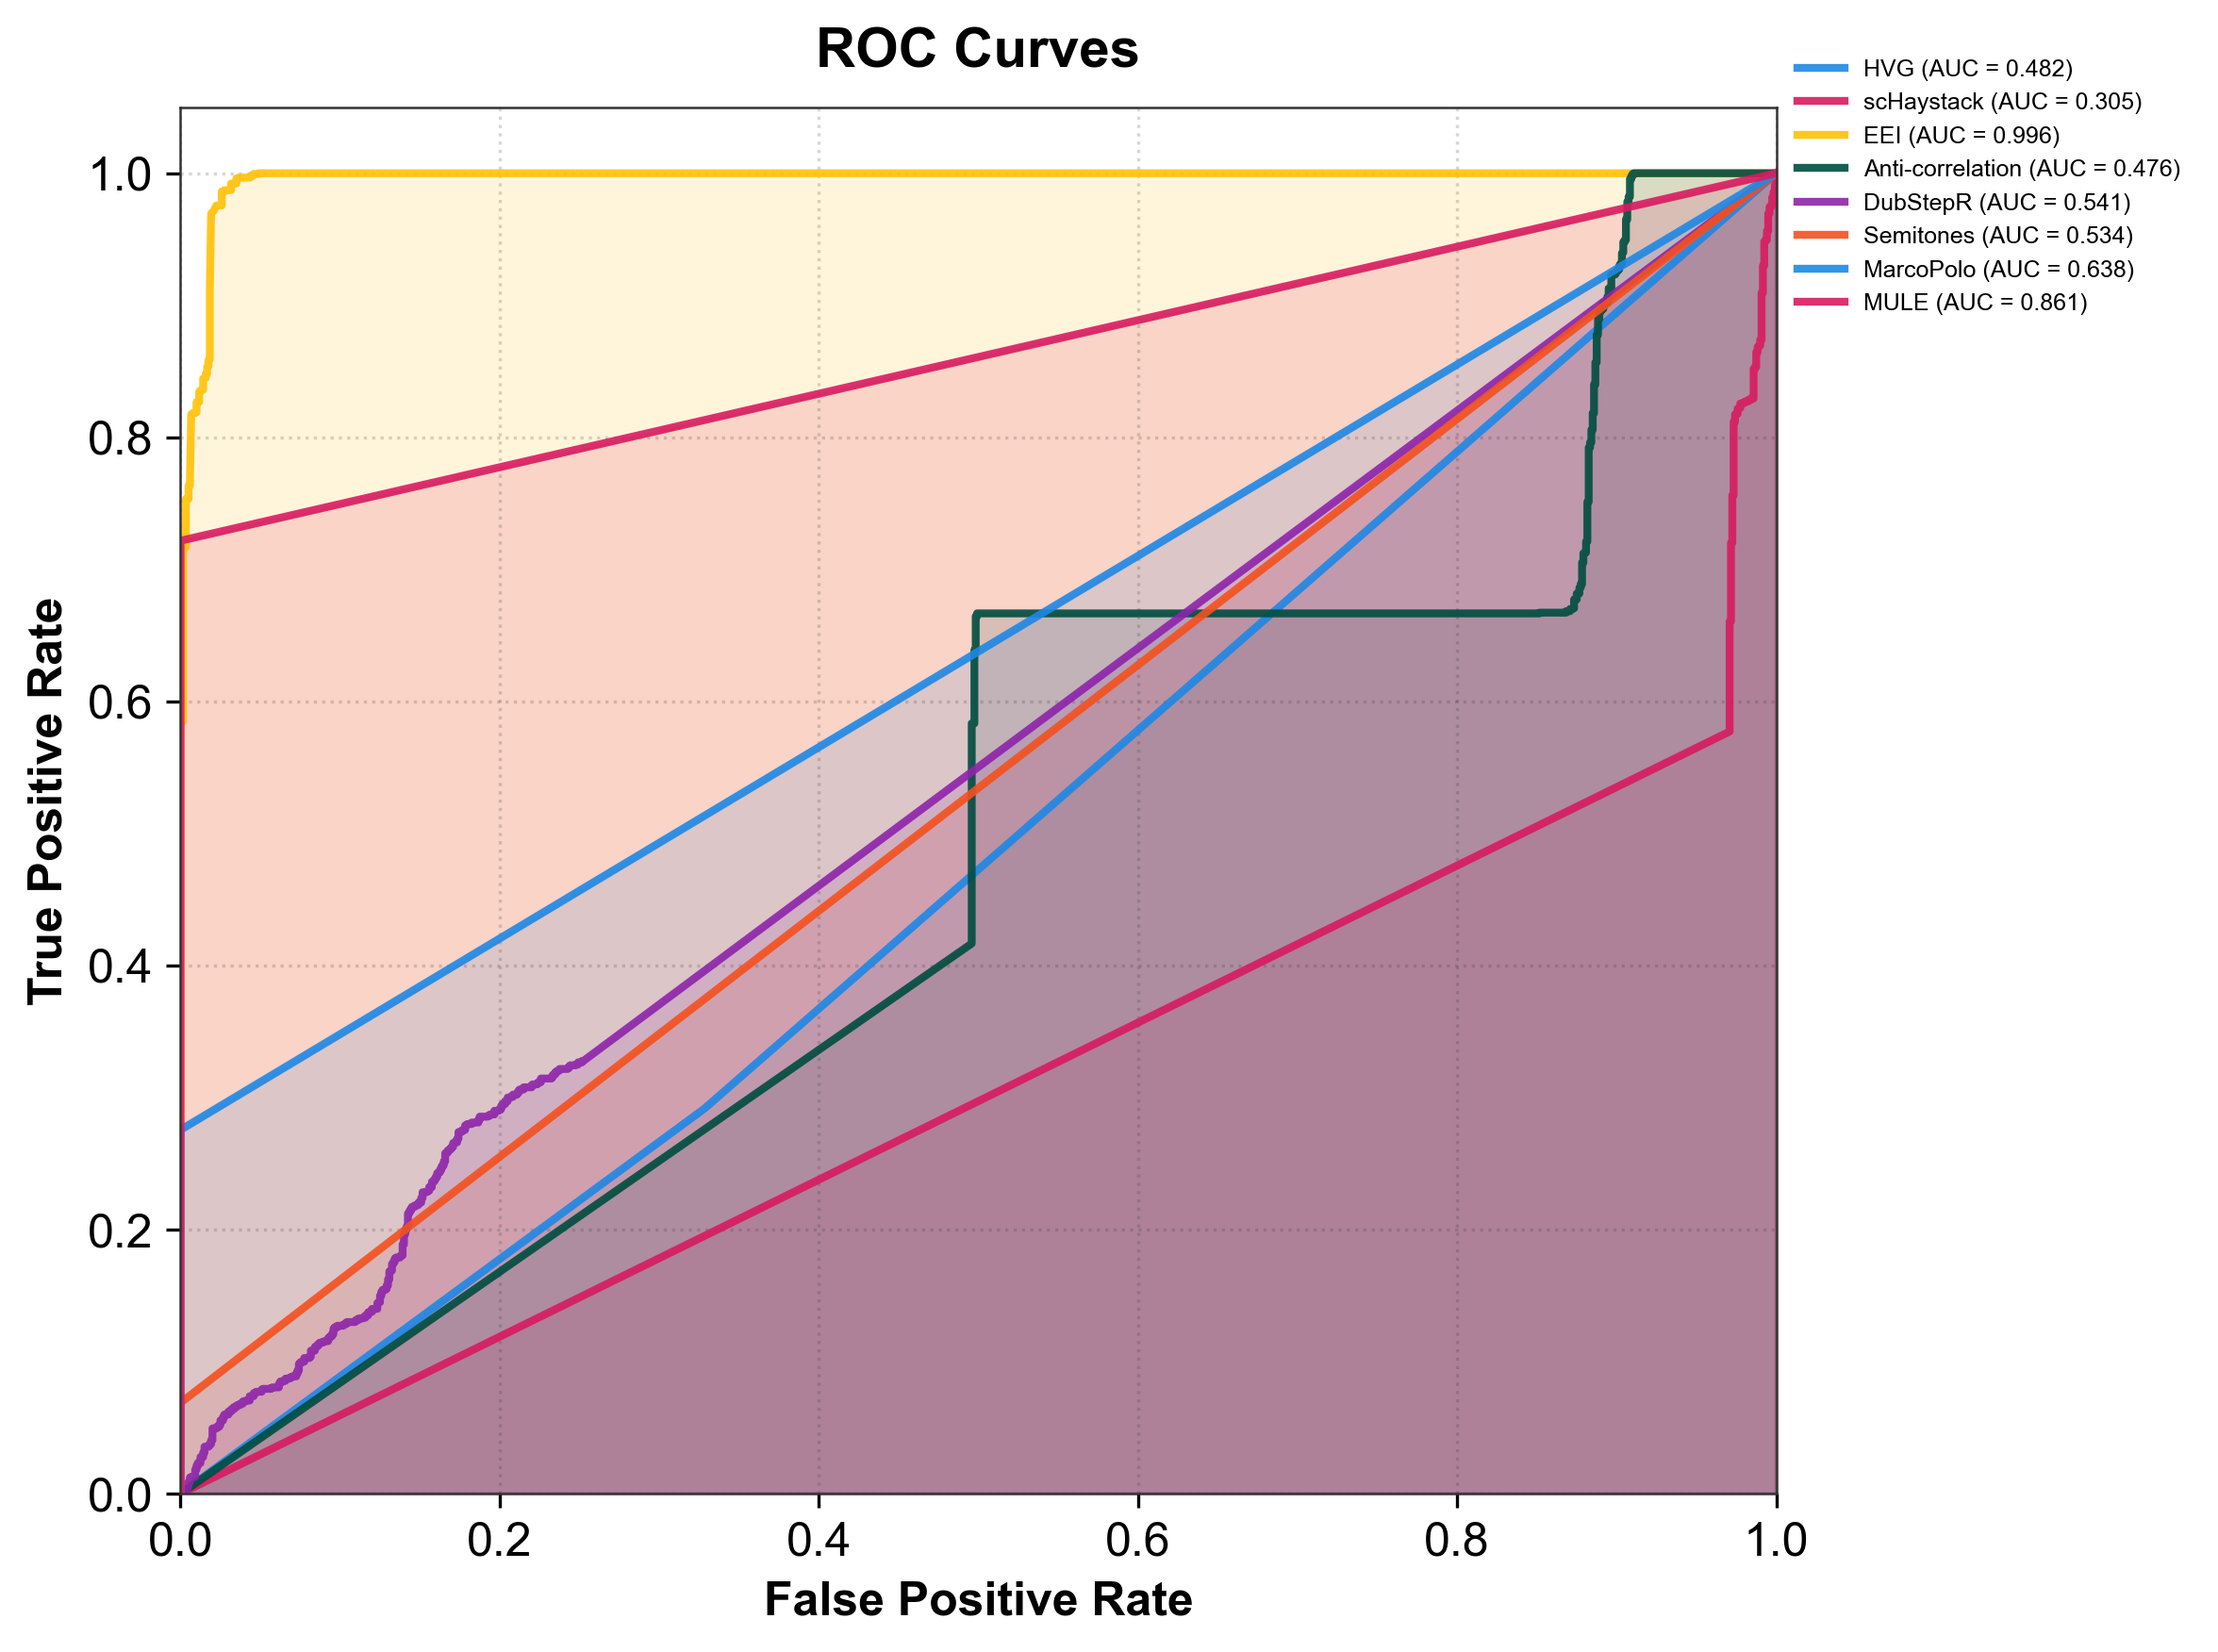

In [30]:
# method_list = ["Anti-correlation"]
# results = evaluate_methods(adata, method_list)
# results['MULE'] = mule_result
# ROC
label = [1 if g in all_markers else 0 for g in adata.var_names]

auc_dict = ROC(label, results)

## 雷达图

In [31]:
# massage
results['MULE']['genes'] = all_markers

In [32]:
# 提取基因类别（属于什么 marker）
def extract_gene_category(gene_name):
        match = gene_name.split("_")
        if match:
            return match[0]
        return "Unknown"

gene_categories = [extract_gene_category(gene) for gene in adata.var_names]
gene_dict = defaultdict(list)
for category, gene_name in zip(gene_categories, adata.var_names):
    gene_dict[category].append(gene_name)

In [33]:
def split_dict_by_group(data):
    result = defaultdict(lambda: defaultdict(list))
    
    for key, values in data.items():
        for v in values:
            parts = v.split("_")
            if len(parts) > 1:
                group = parts[1]   # 比如 "gb0"
                result[group][key].append(v)
    
    return dict(result)

classed_dict = split_dict_by_group(gene_dict)

In [34]:
def radar_chart_from_method_results(method_results, gene_dict, adatas=None, method_colors=None):
    """
    画雷达图，每个角表示一个基因类别，值表示该方法在该类别中找出的基因比例。
    
    参数：
        method_results: dict
            每个 key 是方法名，每个 value 是 {'genes': [...], 'scores': [...]} 的 dict
        gene_dict: dict
            每个 key 是基因类别，value 是该类别的基因列表
        adatas: list of AnnData, optional
            每个方法对应的 AnnData（如果要根据实际选出的基因计算敏感性）
            如果 None，则直接用 method_results['genes'] 计算
        method_colors: list, optional
            每个方法的颜色
    """
    import matplotlib.pyplot as plt

    methods = list(method_results.keys())
    categories = list(gene_dict.keys())
    
    # 默认颜色
    if method_colors is None:
        default_colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e', '#17becf', '#8c564b']
        method_colors = [default_colors[i % len(default_colors)] for i in range(len(methods))]

    # 计算每个方法在每个类别的敏感性
    sensitivity_results = {}
    for i, method in enumerate(methods):
        method_genes = set(method_results[method]['genes'])
        sensitivity = []
        for category, gene_list in gene_dict.items():
            gene_list_set = set(gene_list)
            tp = len(gene_list_set & method_genes)
            num = len(gene_list_set)
            sensitivity.append(tp / num if num > 0 else 0)
        sensitivity_results[method] = sensitivity

    # 画雷达图
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # 闭合

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    for i, method in enumerate(methods):
        values = sensitivity_results[method] + [sensitivity_results[method][0]]
        ax.plot(angles, values, 'o-', linewidth=1.5, label=method, color=method_colors[i], markersize=6)
        ax.fill(angles, values, alpha=0.05, color=method_colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
    ax.set_rlabel_position(30)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_yticklabels([f"{x:.1f}" for x in np.linspace(0, 1, 6)])
    ax.grid(alpha=0.3)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.title("Gene Category Sensitivity Radar Chart", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [35]:
def radar_chart_grid_from_method_results(method_results, classed_dict, merged_blocks=None, method_colors=None, show_xtick=False):
    """
    画一个包含多个子图的网格，每个子图是一个基因强度类别的雷达图，显示每个方法在该强度类别中的基因敏感性。
    支持通过 merged_blocks 字典将多个 gene_strength 的 gene_dict 合并，并使用字典键作为分组名称。
    使用单个图注适用于所有子图。

    参数：
        method_results: dict
            每个 key 是方法名，每个 value 是 {'genes': [...], 'scores': [...]} 的 dict
        classed_dict: dict
            每个 key 是基因强度类别（如 gene_strength），value 是 gene_dict（每个 key 是基因类别，value 是基因列表）
        merged_blocks: dict, optional
            键是用户定义的分组名称，值是需要合并的 gene_strength 列表（如 {"high": ["gb0", "gb1"], "mid": ["gb2", "gb3"]})
            如果为 None，则每个 gene_strength 单独绘制
        method_colors: list, optional
            每个方法的颜色
    """
    # 如果没有提供 merged_blocks，则每个 gene_strength 单独绘制
    if merged_blocks is None:
        gene_strengths = list(classed_dict.keys())
        merged_dicts = [(key, classed_dict[key]) for key in gene_strengths]
    else:
        # 创建合并后的 gene_dict 列表
        merged_dicts = []
        for block_name, gene_strengths in merged_blocks.items():
            # 初始化合并后的 gene_dict
            merged_gene_dict = {}
            # 检查 block 中的所有 gene_strength 是否存在
            for gene_strength in gene_strengths:
                if gene_strength not in classed_dict:
                    raise ValueError(f"Gene strength '{gene_strength}' not found in classed_dict")
            # 合并 gene_dict
            for gene_strength in gene_strengths:
                gene_dict = classed_dict[gene_strength]
                for category, gene_list in gene_dict.items():
                    if category not in merged_gene_dict:
                        merged_gene_dict[category] = []
                    merged_gene_dict[category].extend(gene_list)
            # 去重基因列表以避免重复
            for category in merged_gene_dict:
                merged_gene_dict[category] = list(set(merged_gene_dict[category]))
            # 添加合并后的 gene_dict 和分组名称
            merged_dicts.append((block_name, merged_gene_dict))

    # 设置子图布局
    n_plots = len(merged_dicts)
    ncols = min(n_plots, 3)  # 每行最多3个子图
    nrows = (n_plots + ncols - 1) // ncols  # 计算需要的行数
    fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 10 * nrows), subplot_kw=dict(polar=True))

    # 如果只有一个子图，axes 不是数组，需转换为数组
    if n_plots == 1:
        axes = np.array([[axes]])
    elif n_plots <= ncols:
        axes = axes.reshape(1, -1)
    else:
        axes = axes.reshape(nrows, ncols)

    # 默认颜色
    if method_colors is None:
        method_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']

    # 为每个合并后的 gene_dict 绘制雷达图
    handles, labels = [], []  # 用于存储图注的句柄和标签
    for idx, (title, gene_dict) in enumerate(merged_dicts):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row, col]

        # 获取当前 gene_dict 的类别
        methods = list(method_results.keys())
        categories = list(gene_dict.keys())

        # 计算每个方法在每个类别的敏感性
        sensitivity_results = {}
        for i, method in enumerate(methods):
            method_genes = set(method_results[method]['genes'])
            sensitivity = []
            for category, gene_list in gene_dict.items():
                gene_list_set = set(gene_list)
                tp = len(gene_list_set & method_genes)
                num = len(gene_list_set)
                sensitivity.append(tp / num if num > 0 else 0)
            sensitivity_results[method] = sensitivity

        # 准备角度
        N = len(categories)
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        angles += angles[:1]  # 闭合

        # 设置最大半径为1.0
        max_val = 1.0
        radial_ticks = np.linspace(0, max_val, 6)

        # 绘制多边形背景（从最外层开始向内绘制）
        for i in range(len(radial_ticks)-1, 0, -1):
            r = radial_ticks[i]
            poly_angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
            poly_angles.append(poly_angles[0])
            poly_r = [r] * (N + 1)
            color = (0.95, 0.95, 0.95) if i % 2 == 0 else 'white'
            ax.fill(poly_angles, poly_r, color=color, alpha=0.7)

        # 绘制最外层1.0的六边形边框
        outer_poly_angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        outer_poly_angles.append(outer_poly_angles[0])
        outer_poly_r = [max_val] * (N + 1)
        ax.plot(outer_poly_angles, outer_poly_r, color='lightgray', linewidth=1.5)

        # 绘制放射状网格线
        for angle in angles[:-1]:
            ax.plot([0, angle], [0, max_val], color='lightgray', linestyle='-', alpha=0.5)

        # 绘制数据线
        for i, method in enumerate(methods):
            values = sensitivity_results[method] + [sensitivity_results[method][0]]
            color = method_colors[i % len(method_colors)]
            line, = ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color, markersize=0)
            ax.fill(angles, values, color=color, alpha=0.1)
            # 只在第一个子图收集图注句柄
            if idx == 0:
                handles.append(line)
                labels.append(method)

        # 设置标签和美化
        ax.set_xticks(angles[:-1])
        if show_xtick:
            ax.set_xticklabels(categories, fontsize=14, fontweight='bold')
        else:
            ax.set_xticklabels("")
        ax.grid(False)
        ax.set_rticks([])
        ax.set_rgrids([])
        ax.spines['polar'].set_visible(False)
        ax.set_rlabel_position(0)
        ax.set_ylim(0, max_val)
        ax.set_title(f"Gene Strength: {title}", fontsize=16, fontweight='bold', pad=20)

    # 隐藏多余的子图（如果有）
    for idx in range(len(merged_dicts), nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].set_visible(False)

    # 添加单个图注
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=12)

    # 调整布局并添加主标题
    # plt.suptitle("Gene Category Sensitivity Radar Charts by Gene Strength", fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])  # 调整以留出空间给图注和主标题
    plt.show()

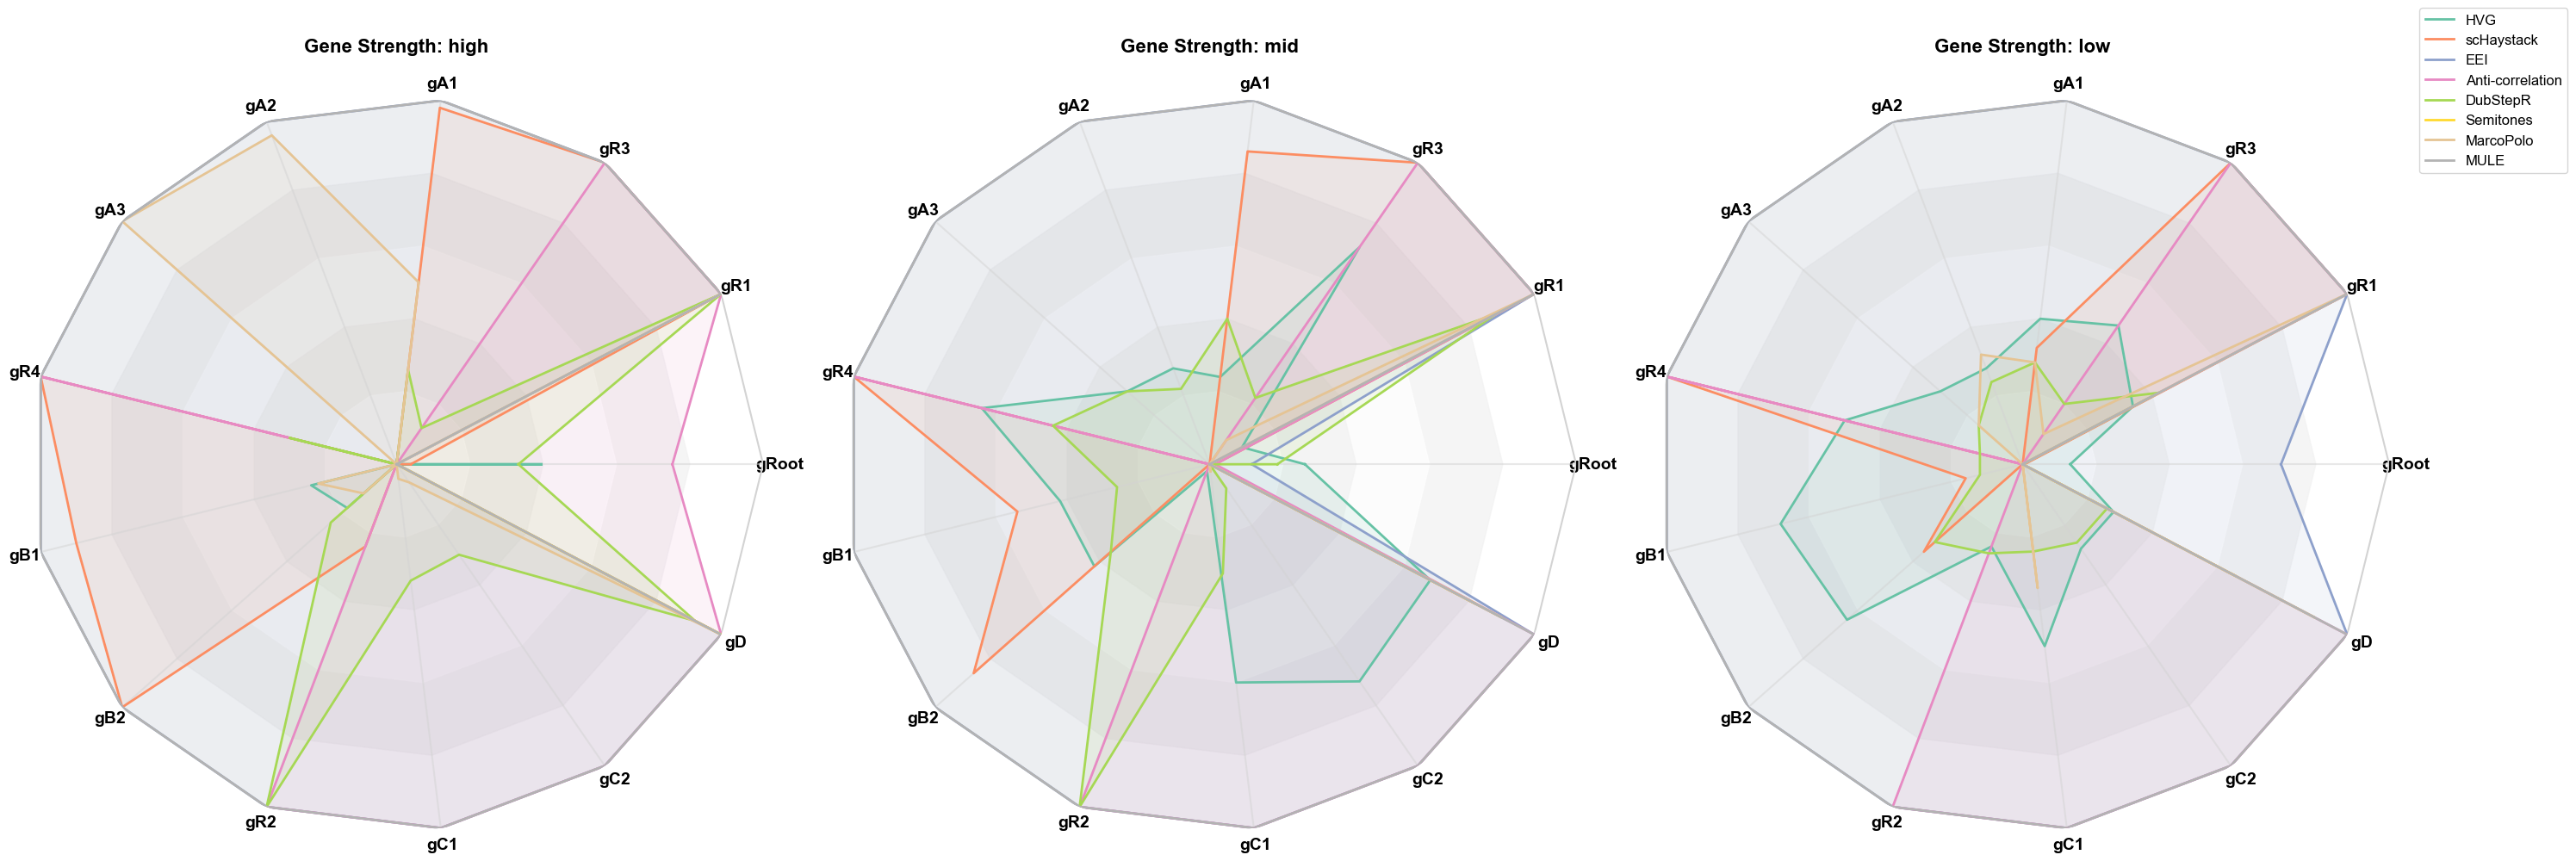

In [36]:
radar_chart_grid_from_method_results(results, classed_dict, merged_blocks={"high": ['gb0', 'gb3'], "mid": ["gb1"], "low": ["gb2"]}, show_xtick=True)

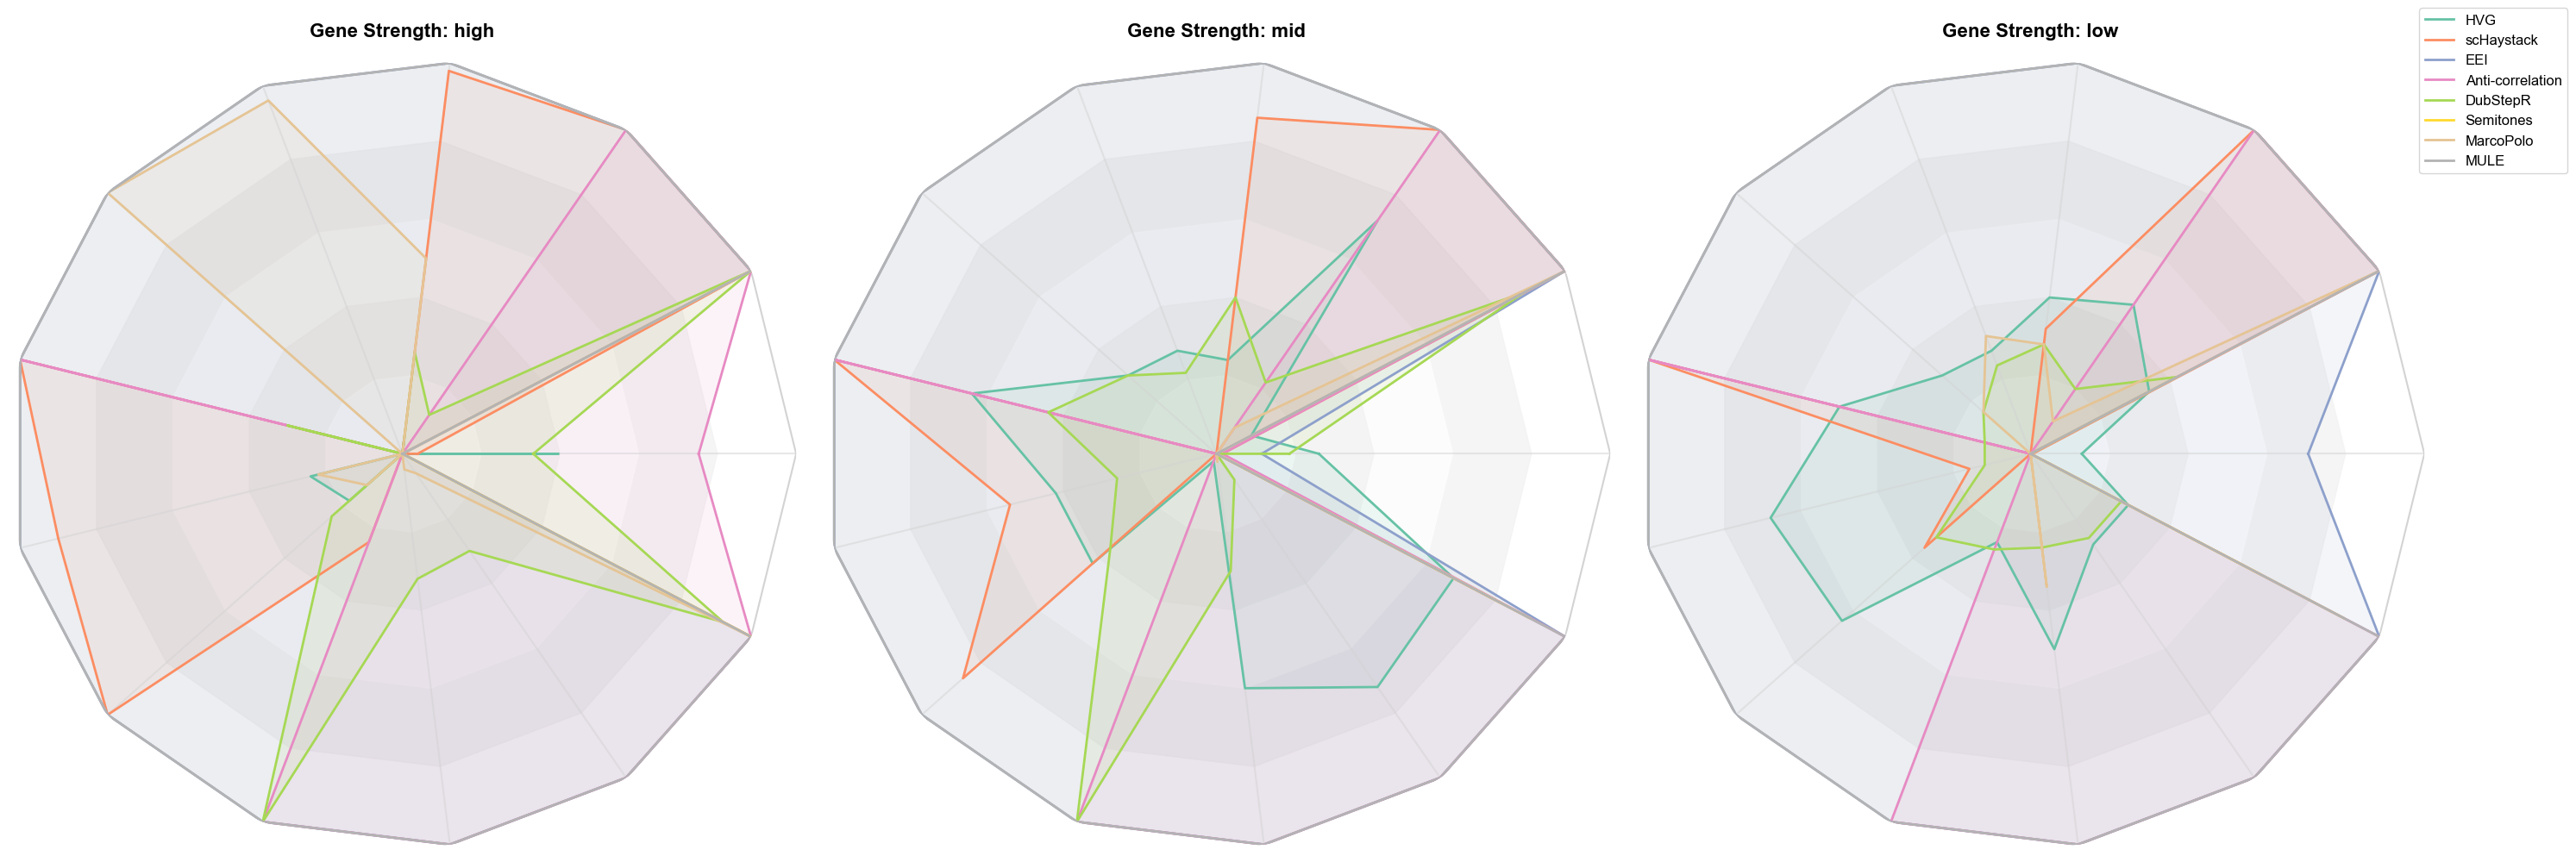

In [37]:
# method_list = ["Anti-correlation", "DubStepR"]
# results = evaluate_methods(adata, method_list)
# results['MULE'] = mule_result
# for gene_strength in classed_dict:
#     radar_chart_from_method_results(results, classed_dict[gene_strength])
radar_chart_grid_from_method_results(results, classed_dict, merged_blocks={"high": ['gb0', 'gb3'], "mid": ["gb1"], "low": ["gb2"]})

In [38]:
# def ROC(label, method_results):
#     import matplotlib.pyplot as plt
#     from sklearn.metrics import roc_curve, auc
#     import numpy as np

#     colors = ['darkorange', 'green', 'red', 'blue', 'purple', 'brown']
#     names = list(method_results.keys())

#     plt.figure(figsize=(8, 8))

#     for i, name in enumerate(names):
#         res = method_results[name]
#         genes = res["genes"]
#         scores = res["scores"]

#         # 内部排序，按 score 降序排列基因
#         sorted_indices = np.argsort(scores)[::-1]
#         sorted_genes = [genes[j] for j in sorted_indices]
#         sorted_scores = [scores[j] for j in sorted_indices]

#         # 创建与 label 对齐的分数数组
#         gene_to_score = dict(zip(sorted_genes, sorted_scores))
#         scores_array = np.array([gene_to_score.get(g, 0) for g in adata.var_names])

#         # 计算 ROC
#         fpr, tpr, _ = roc_curve(label, scores_array)
#         roc_auc = auc(fpr, tpr)

#         # 画 ROC 曲线
#         plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
#                  label=f'{name} (AUC = {roc_auc:.3f})')

#         # 打印 AUC
#         print(f"{name}: AUC = {roc_auc:.4f}")

#     # 图形美化
#     plt.axis('off')
#     for spine in plt.gca().spines.values():
#         spine.set_visible(False)
#     plt.legend(loc='lower right', frameon=True, fontsize=10, edgecolor='black')
#     plt.tight_layout()
#     plt.show()

In [39]:
# method_list = ["Anti-correlation"]
# results = evaluate_methods(adata, method_list)

# # ROC
# label = [1 if g in all_markers else 0 for g in adata.var_names]
# auc_dict = ROC(label, results)

# # 取 gene list
# anti_genes = results["Anti-correlation"]["genes"]

## UMAP

In [40]:
def plot_umap_by_method(adata, method_results, random_state=0):
    """
    为每个方法选出的基因绘制 UMAP。
    
    参数：
        adata: AnnData
            原始数据
        method_results: dict
            每个方法名对应 {'genes': [...], 'scores': [...]}
        random_state: int
            随机种子，用于 PCA/UMAP reproducibility
    """
    methods = list(method_results.keys())
    
    for method in methods:
        genes = method_results[method]['genes']
        
        # 保留原始 adata 不变
        adata_sub = adata[:, [g for g in genes if g in adata.var_names]].copy()
        
        # 标准化和 log1p（Scanpy 推荐流程）
        sc.pp.normalize_total(adata_sub)
        sc.pp.log1p(adata_sub)
        sc.pp.scale(adata_sub)
        
        # PCA + UMAP
        sc.tl.pca(adata_sub, svd_solver='arpack', random_state=random_state)
        sc.pp.neighbors(adata_sub, n_pcs=min(50, adata_sub.obsm['X_pca'].shape[1]))
        sc.tl.umap(adata_sub, random_state=random_state)
        
        # 绘图
        sc.pl.umap(adata_sub, color='cell_type', title=f"UMAP ({method})", show=True)

In [41]:
def plot_umap_by_method(adata, method_results, random_state=0, resolution=0.5):
    """
    为每个方法选出的基因绘制 UMAP 子图，带正方形边框，第一行显示方法名称，
    并返回各方法与 ground truth 的 ARI 值。优化为复用预处理和 UMAP 计算。

    参数：
        adata: AnnData
            原始数据
        method_results: dict
            每个方法名对应 {'genes': [...], 'scores': [...]}
        random_state: int
            随机种子，用于 PCA/UMAP reproducibility
        resolution: float
            Leiden 聚类分辨率

    返回：
        pd.DataFrame
            一行 DataFrame，列为方法名，值为对应方法的 ARI
    """
    methods = list(method_results.keys())
    n_methods = len(methods)
    ari_scores = {}

    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.sans-serif'] = ['Arial']
    plt.rcParams['font.size'] = 20
    font_size = 20
    
    # 创建子图：2 行 n_methods 列，确保每个子图近似正方形
    fig, axs = plt.subplots(n_methods, 2, figsize=(4 * 2.3, 4 * n_methods), dpi=100)
    if n_methods == 1:
        axs = axs.reshape(2, 1)  # 确保是 2D 数组
    
    # 获取 cell_type 的颜色调色板
    palette = sns.color_palette("husl", len(adata.obs['cell_type'].cat.categories))
    
    # 循环每个方法，复用预处理和 UMAP
    for i, method in enumerate(methods):
        genes = method_results[method]['genes']
        
        # 保留原始 adata 不变，创建子集
        print("genes: ", [g for g in genes if g in adata.var_names])
        adata_sub = adata[:, [g for g in genes if g in adata.var_names]].copy()
        
        # 标准化和 log1p（Scanpy 推荐流程）
        sc.pp.normalize_total(adata_sub)
        sc.pp.log1p(adata_sub)
        sc.pp.scale(adata_sub)
        
        # PCA + neighbors
        sc.tl.pca(adata_sub, svd_solver='arpack', random_state=random_state)
        sc.pp.neighbors(adata_sub, n_pcs=min(50, adata_sub.obsm['X_pca'].shape[1]), n_neighbors=80)
        
        # Leiden 聚类
        sc.tl.leiden(adata_sub, resolution=resolution, random_state=random_state)
        
        # 计算 ARI
        ari_scores[method] = adjusted_rand_score(adata_sub.obs['leiden'], adata_sub.obs['cell_type'])
        
        # 计算 UMAP
        sc.tl.umap(adata_sub, spread=20, random_state=random_state)
        
        # 第一行：Leiden 聚类，带方法名称
        sc.pl.umap(adata_sub, color='leiden', ax=axs[i, 0], show=False, frameon=True)
        axs[i, 0].set_title('')
        axs[i, 0].set_xlabel('')
        axs[i, 0].set_ylabel(method)
        for spine in axs[i, 0].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
        
        # 第二行：真实标签 cell_type，使用相同 UMAP 嵌入
        sc.pl.umap(adata_sub, color='cell_type', palette=palette, ax=axs[i, 1], show=False, frameon=True)
        axs[i, 1].set_title('')
        axs[i, 1].set_xlabel('')
        axs[i, 1].set_ylabel('')
        for spine in axs[i, 1].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)

    # 设置标注
    axs[0, 0].set_title('Cluster', fontsize=font_size)
    axs[0, 1].set_title('Ground Truth', fontsize=font_size)

    # 调整布局：移除多余间距，确保正方形
    plt.tight_layout()
    fig.subplots_adjust(wspace=0.02, hspace=0.1)
    plt.show()

    # 返回 ARI 值的 DataFrame
    return pd.DataFrame([ari_scores])

genes:  ['gRoot_gb0_1', 'gRoot_gb0_3', 'gRoot_gb0_4', 'gRoot_gb0_5', 'gRoot_gb0_6', 'gRoot_gb0_8', 'gRoot_gb0_9', 'gRoot_gb0_10', 'gRoot_gb0_13', 'gRoot_gb0_14', 'gRoot_gb0_15', 'gRoot_gb0_19', 'gRoot_gb0_25', 'gRoot_gb0_26', 'gRoot_gb0_34', 'gRoot_gb0_35', 'gRoot_gb0_37', 'gRoot_gb0_41', 'gRoot_gb0_42', 'gRoot_gb0_44', 'gRoot_gb0_45', 'gRoot_gb0_52', 'gRoot_gb0_54', 'gRoot_gb0_55', 'gRoot_gb0_56', 'gRoot_gb0_61', 'gRoot_gb0_64', 'gRoot_gb0_68', 'gRoot_gb0_69', 'gRoot_gb0_71', 'gRoot_gb0_72', 'gRoot_gb0_74', 'gRoot_gb0_75', 'gRoot_gb0_76', 'gRoot_gb0_78', 'gRoot_gb0_82', 'gRoot_gb0_83', 'gRoot_gb0_86', 'gRoot_gb0_89', 'gRoot_gb0_90', 'gRoot_gb0_91', 'gRoot_gb0_92', 'gRoot_gb0_93', 'gRoot_gb0_94', 'gRoot_gb0_95', 'gRoot_gb0_97', 'gRoot_gb0_99', 'gRoot_gb0_100', 'gRoot_gb0_101', 'gRoot_gb0_103', 'gRoot_gb0_104', 'gRoot_gb0_105', 'gRoot_gb0_106', 'gRoot_gb0_108', 'gRoot_gb0_110', 'gRoot_gb0_111', 'gRoot_gb0_113', 'gRoot_gb0_114', 'gRoot_gb0_115', 'gRoot_gb0_117', 'gRoot_gb0_119', 'gRoot_g

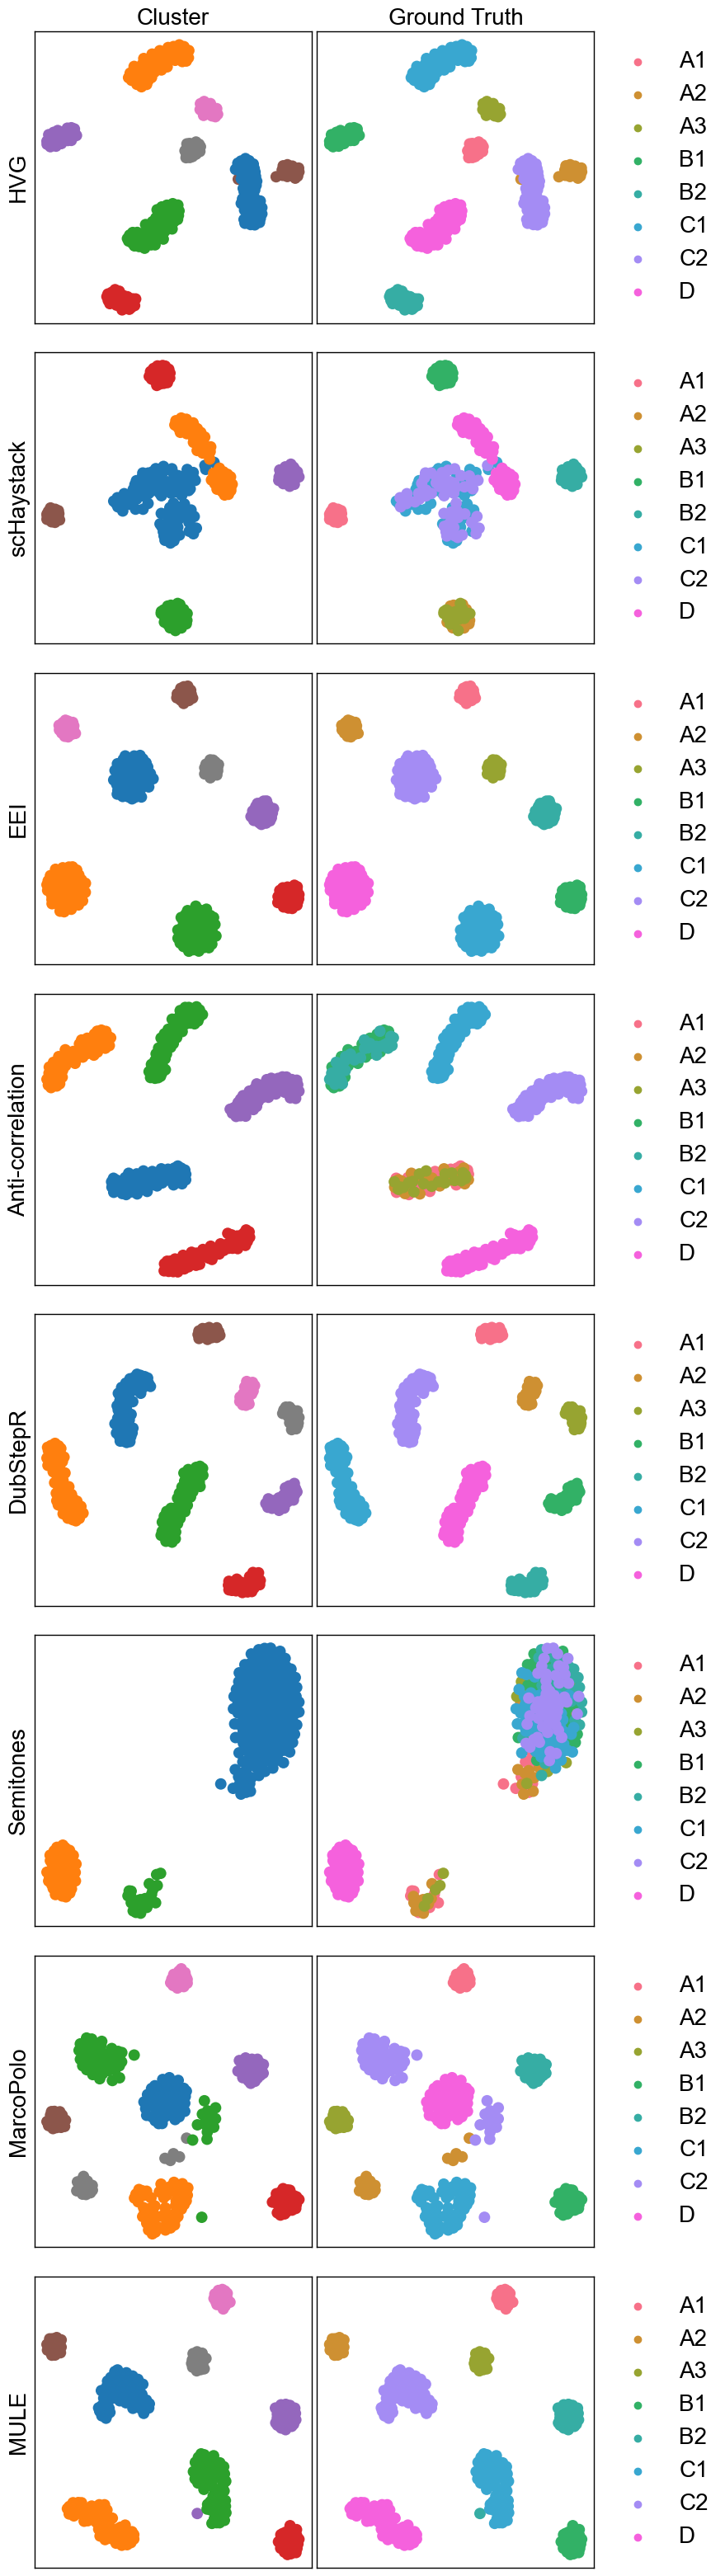

,HVG,scHaystack,EEI,Anti-correlation,DubStepR,Semitones,MarcoPolo,MULE
0,1.0,0.719578,1.0,0.837664,1.0,0.222691,1.0,1.0


In [42]:
ARI_results = plot_umap_by_method(adata, results)
ARI_results

## ARI

In [43]:
def plot_method_ari(df):
    """
    输入: df，列是方法，行是不同情况下的 ARI。
    输出: 每个方法一个 bar (平均 ARI)，颜色来自 husl。
    """
    # 每个方法的平均 ARI
    mean_ari = df.mean(axis=0)
    
    # 调色板
    palette = sns.color_palette("husl", n_colors=len(mean_ari))
    
    # 画 barplot
    plt.figure(figsize=(4,1.5), dpi=300)
    plt.rcParams['font.size'] = 6
    sns.barplot(x=mean_ari.index, y=mean_ari.values, palette=palette)
    
    plt.ylabel("Mean ARI")
    plt.xlabel("Method")
    plt.title("Clustering Performance by Method")
    plt.tight_layout()
    plt.show()

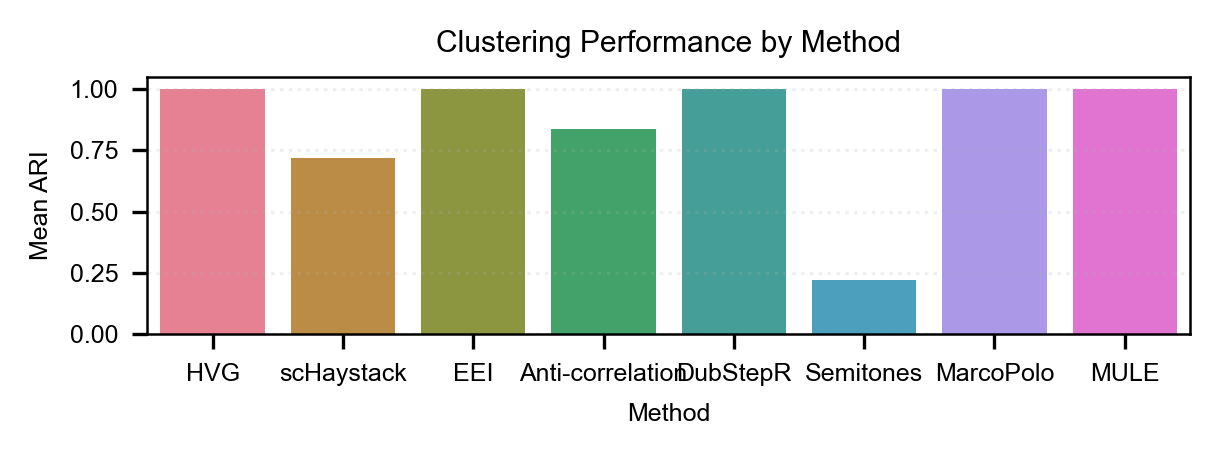

In [44]:
plot_method_ari(ARI_results)